In [1]:
# Manejo de directorios y rutas
import os

# Computación numérica y manejo de matrices
import numpy as np

# Manejo y preprocesamiento de datos
import pandas as pd

# Librerías para graficación
from matplotlib import pyplot

# Mostrar gráficos dentro del cuadernillo
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
import random

In [3]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("CUDA de PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

#si queremos mejorar este codigo deberiamos de usar el siguiente para que se use cuda siempre y cuando existan esos nuvles y si no permanecer en cpu
#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(f'Dispositivo en uso: {device}')
#print(f'Versión de PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cu132
CUDA disponible: True
CUDA de PyTorch: 13.2
GPU: NVIDIA GeForce RTX 5050 Laptop GPU


intento con formato numpy


In [5]:
df_emnist = np.load('dt_p/mnist.npz')

In [6]:
print("Archivos en el dataset:", df_emnist.files)

Archivos en el dataset: ['x_test', 'x_train', 'y_train', 'y_test']


In [8]:
X_train_emnist = df_emnist['x_train']
y_train_emnist = df_emnist['y_train']
X_test_emnist = df_emnist['x_test']
y_test_emnist = df_emnist['y_test']

print("Tamaño de X_train:", X_train_emnist.shape)
print("Tamaño de y_train:", y_train_emnist.shape)
print("Tamaño de X_test:", X_test_emnist.shape)
print("Tamaño de y_test:", y_test_emnist.shape)


Tamaño de X_train: (60000, 28, 28)
Tamaño de y_train: (60000,)
Tamaño de X_test: (10000, 28, 28)
Tamaño de y_test: (10000,)


In [13]:


print("Lista de clases únicas:", np.unique(y_train_emnist))
print("Cantidad total de clases:", len(np.unique(y_train_emnist)))

Lista de clases únicas: [0 1 2 3 4 5 6 7 8 9]
Cantidad total de clases: 10


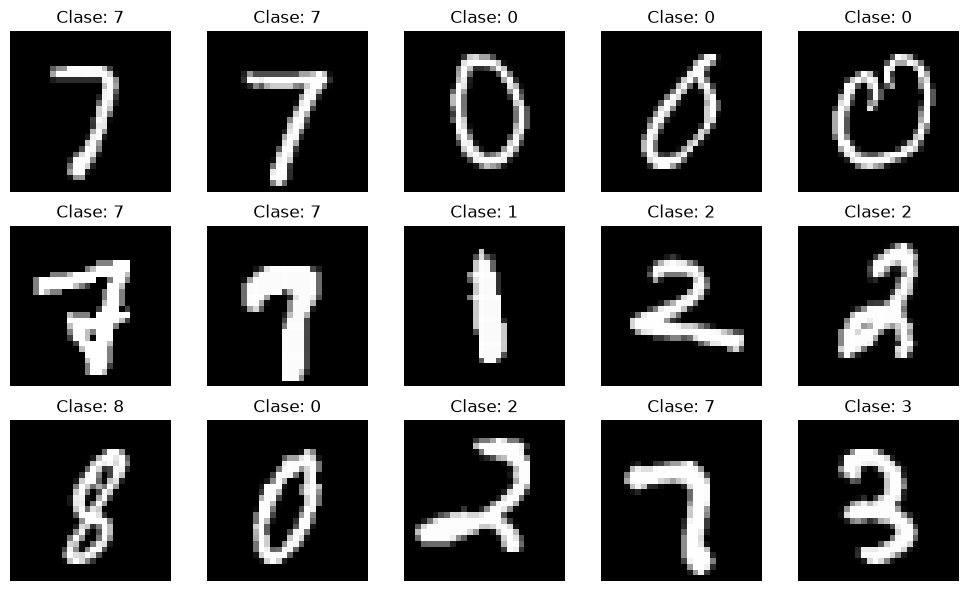

In [9]:
r, c = 3, 5

fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):

        plt.subplot(r, c, _r*c + _c + 1)

        ix = random.randint(0, len(X_train_emnist) - 1)

        img = X_train_emnist[ix]

        plt.imshow(
            img.reshape(28, 28),
            cmap="gray"
        )

        plt.axis("off")
        plt.title(f"Clase: {y_train_emnist[ix]}")

plt.tight_layout()
plt.show()

In [11]:
# Normalizamos los píxeles
X_train_emnist = X_train_emnist / 255.0
X_test_emnist = X_test_emnist / 255.0

# Convertimos las etiquetas a enteros
y_train_emnist = y_train_emnist.astype(np.int64)
y_test_emnist = y_test_emnist.astype(np.int64)

In [12]:
import torch

X_train_emnist_t = torch.tensor(
    X_train_emnist,
    dtype=torch.float32
).cuda()

X_test_emnist_t = torch.tensor(
    X_test_emnist,
    dtype=torch.float32
).cuda()

y_train_emnist_t = torch.tensor(
    y_train_emnist,
    dtype=torch.long
).cuda()

y_test_emnist_t = torch.tensor(
    y_test_emnist,
    dtype=torch.long
).cuda()

In [15]:
# Aplanar el conjunto de entrenamiento (60000, 28, 28) -> (60000, 784)
X_train_emnist_t = X_train_emnist_t.reshape(X_train_emnist_t.shape[0], -1)

# Aplanar el conjunto de prueba (10000, 28, 28) -> (10000, 784)
X_test_emnist_t = X_test_emnist_t.reshape(X_test_emnist_t.shape[0], -1)

# Verificar dimensiones
print("Forma X_train:", X_train_emnist_t.shape)  # torch.Size([60000, 784])
print("Forma X_test:", X_test_emnist_t.shape)    # torch.Size([10000, 784])

Forma X_train: torch.Size([60000, 784])
Forma X_test: torch.Size([10000, 784])


In [16]:
D_in, H1, D_out = 784, 100, 10
model_emnist = torch.nn.Sequential(
torch.nn.Linear(D_in, H1),
torch.nn.ReLU(),
torch.nn.Dropout(0.2),
torch.nn.Linear(H1, D_out),
).cuda()

criterion_emnist = torch.nn.CrossEntropyLoss()

optimizer_emnist = torch.optim.Adam(model_emnist.parameters(), lr=0.008)

epochs = 1800
log_each = 10

l_emnist = []

model_emnist.train()

for e in range(1, epochs + 1):

    # Forward
    y_pred_emnist = model_emnist(X_train_emnist_t)

    # Loss
    loss_emnist = criterion_emnist(
        y_pred_emnist,
        y_train_emnist_t
    )

    l_emnist.append(loss_emnist.item())

    # Ponemos a cero los gradientes
    optimizer_emnist.zero_grad()

    # Backpropagation
    loss_emnist.backward()

    # Actualizamos los pesos
    optimizer_emnist.step()

    if not e % log_each:
        print(
            f"Epoch {e}/{epochs} "
            f"Loss {np.mean(l_emnist):.5f}"
        )

Epoch 10/1800 Loss 2.29351
Epoch 20/1800 Loss 2.26959
Epoch 30/1800 Loss 2.22755
Epoch 40/1800 Loss 2.16591
Epoch 50/1800 Loss 2.08773
Epoch 60/1800 Loss 1.99945
Epoch 70/1800 Loss 1.90798
Epoch 80/1800 Loss 1.81850
Epoch 90/1800 Loss 1.73395
Epoch 100/1800 Loss 1.65566
Epoch 110/1800 Loss 1.58363
Epoch 120/1800 Loss 1.51766
Epoch 130/1800 Loss 1.45723
Epoch 140/1800 Loss 1.40192
Epoch 150/1800 Loss 1.35120
Epoch 160/1800 Loss 1.30456
Epoch 170/1800 Loss 1.26161
Epoch 180/1800 Loss 1.22195
Epoch 190/1800 Loss 1.18529
Epoch 200/1800 Loss 1.15133
Epoch 210/1800 Loss 1.11975
Epoch 220/1800 Loss 1.09034
Epoch 230/1800 Loss 1.06286
Epoch 240/1800 Loss 1.03716
Epoch 250/1800 Loss 1.01308
Epoch 260/1800 Loss 0.99045
Epoch 270/1800 Loss 0.96915
Epoch 280/1800 Loss 0.94907
Epoch 290/1800 Loss 0.93009
Epoch 300/1800 Loss 0.91211
Epoch 310/1800 Loss 0.89509
Epoch 320/1800 Loss 0.87892
Epoch 330/1800 Loss 0.86355
Epoch 340/1800 Loss 0.84893
Epoch 350/1800 Loss 0.83498
Epoch 360/1800 Loss 0.82167
E

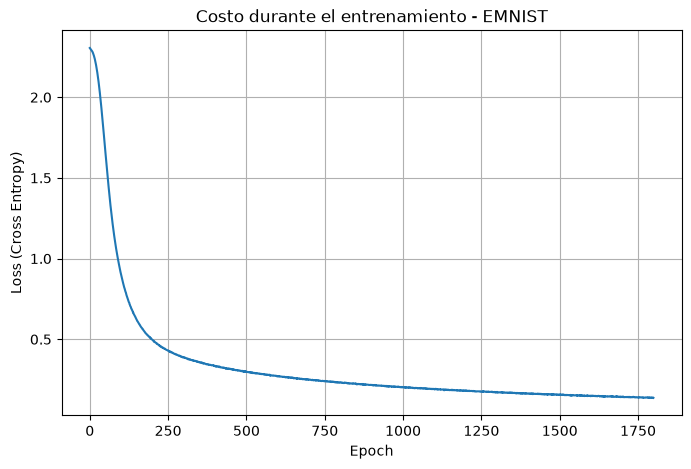

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(l_emnist)

plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.title("Costo durante el entrenamiento - EMNIST")

plt.grid()
plt.show()

In [18]:
from sklearn.metrics import accuracy_score

def evaluate_emnist(x):

    model_emnist.eval()

    # Forward
    logits = model_emnist(x)

    # Convertimos logits a probabilidades
    probabilidades = torch.softmax(logits, dim=1)

    # Elegimos la clase con mayor probabilidad
    predicciones = torch.argmax(
        probabilidades,
        dim=1
    )

    return predicciones

In [19]:
y_pred_emnist = evaluate_emnist(
    X_test_emnist_t
)

accuracy_emnist = accuracy_score(
    y_test_emnist_t.cpu().numpy(),
    y_pred_emnist.cpu().numpy()
)

print(f"Accuracy: {accuracy_emnist * 100:.2f}%")

Accuracy: 96.46%


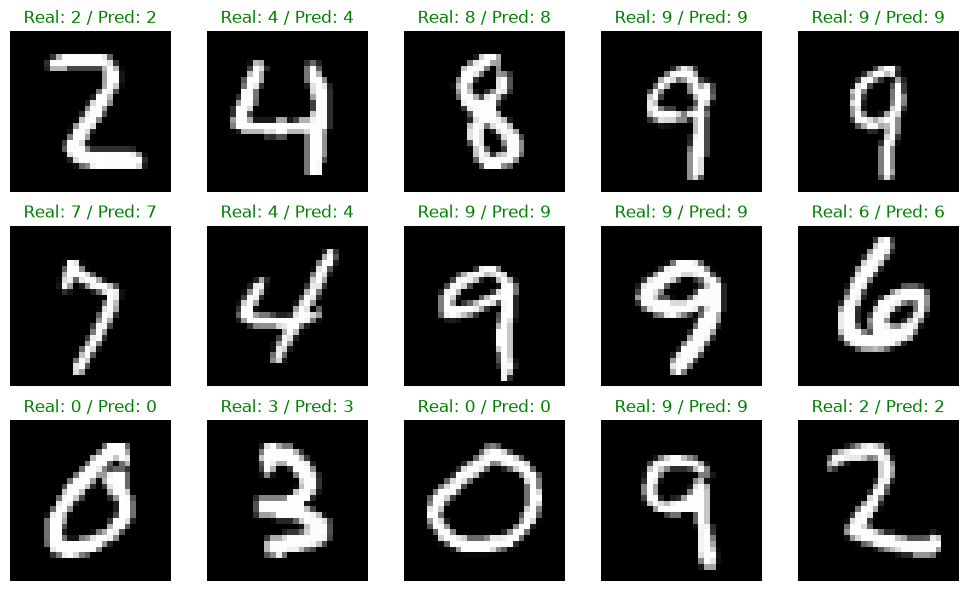

In [22]:
r, c = 3, 5
fig = plt.figure(figsize=(2*c, 2*r))

for _r in range(r):
    for _c in range(c):

        plt.subplot(r, c, _r*c + _c + 1)

        ix = random.randint(0, len(X_test_emnist) - 1)

        img = X_test_emnist[ix]
        y_real = y_test_emnist[ix]

        # 1. Convertir a tensor y APLANAR a (1, 784)
        img_tensor = torch.tensor(img, dtype=torch.float32, device="cuda").reshape(1, -1)

        # 2. Evaluar
        y_pred = evaluate_emnist(img_tensor)[0].item()

        # 3. Graficar (asegurando que img sea 28x28 para plt.imshow)
        plt.imshow(
            img.reshape(28, 28),
            cmap="gray"
        )

        plt.axis("off")

        plt.title(
            f"Real: {y_real} / Pred: {y_pred}",
            color="green" if y_real == y_pred else "red"
        )

plt.tight_layout()
plt.show()